In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

df = pd.read_csv('data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
df.shape

(8807, 12)

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
# Fill text columns where missing means "we don't know"
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Drop the few rows missing critical fields
df = df.dropna(subset=['date_added', 'rating', 'duration'])

# Verify everything is clean
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [14]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df[['title', 'date_added', 'year_added']].head()

AttributeError: Can only use .str accessor with string values, not datetime64

In [15]:
df[['title', 'date_added', 'year_added']].head()

,title,date_added,year_added
0,Dick Johnson Is Dead,2021-09-25,2021
1,Blood & Water,2021-09-24,2021
2,Ganglands,2021-09-24,2021
3,Jailbirds New Orleans,2021-09-24,2021
4,Kota Factory,2021-09-24,2021


In [16]:
type_counts = df['type'].value_counts()
type_pcts = (df['type'].value_counts(normalize=True) * 100).round(1)
print(type_counts)
print()
print(type_pcts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

type
Movie      69.7
TV Show    30.3
Name: proportion, dtype: float64


Content Type Split
Netflix's library is **69.7% Movies** (6,126 titles) and **30.3% TV Shows** (2,664 titles) — a roughly 70/30 split favouring film content.

In [19]:
#Titles added per year
titles_per_year = df['year_added'].value_counts().sort_index()
print(titles_per_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


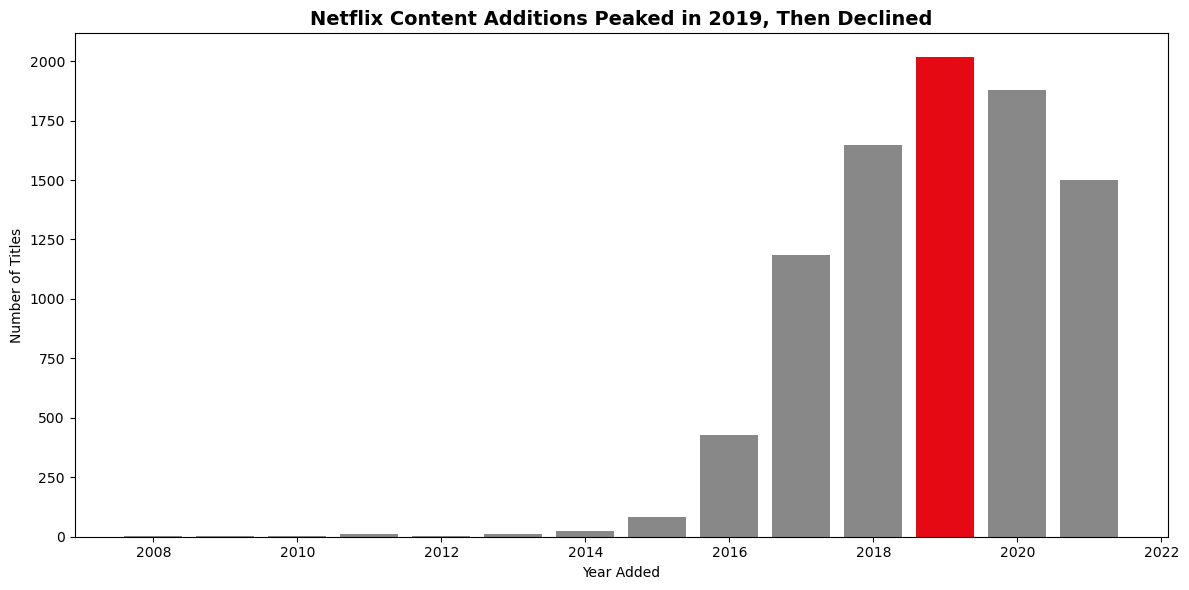

In [26]:
plt.figure(figsize=(12,6))
colors = ['#E50914' if year == 2019 else '#888888' for year in titles_per_year.index]
plt.bar(titles_per_year.index, titles_per_year.values, color=colors)
plt.title('Netflix Content Additions Peaked in 2019, Then Declined', fontsize=14, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.savefig('images/titles_per_year.png', dpi=150)
plt.show()

### Content Additions Over Time
Netflix's content additions grew rapidly from 2015, peaking at **2,016 titles in 2019**, then declined in 2020-2021. This suggests a shift from aggressive catalogue expansion toward a more selective content strategy.

In [35]:
#Top 10 countries by content
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


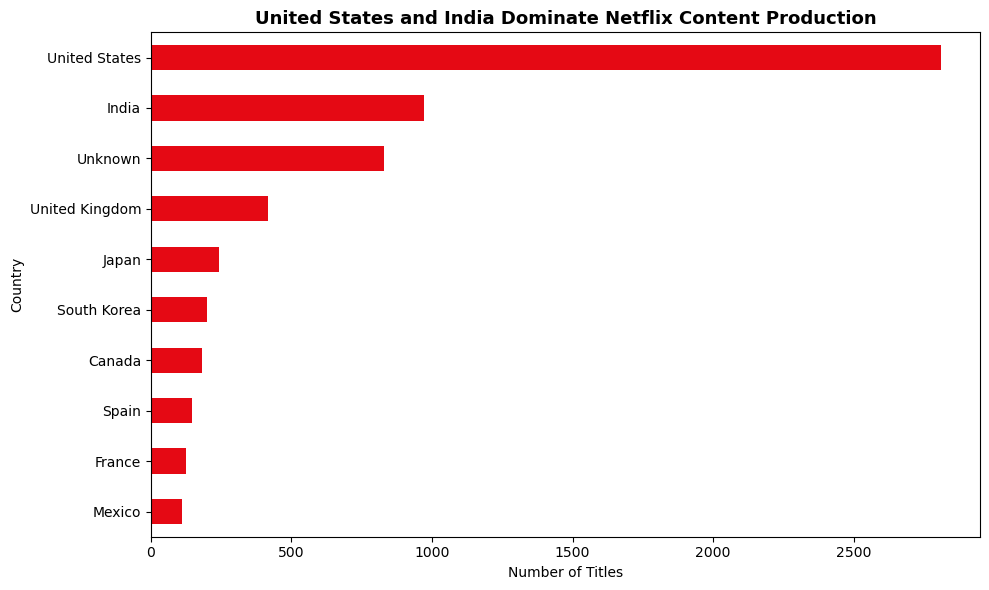

In [27]:
plt.figure(figsize=(10,6))
top_countries.sort_values().plot(kind='barh', color='#E50914')
plt.title('United States and India Dominate Netflix Content Production', fontsize=13, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('images/top_countries.png', dpi=150)
plt.show()

### Top Content-Producing Countries
The United States leads overwhelmingly with **2,809 titles**, followed by India (972) and the UK (418). 

*Caveat: 829 titles ("Unknown") have no country recorded, ranking 3rd. This is a data-quality limitation to note when interpreting country-level rankings.*

In [34]:
#Most common genres
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
print(top_genres)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


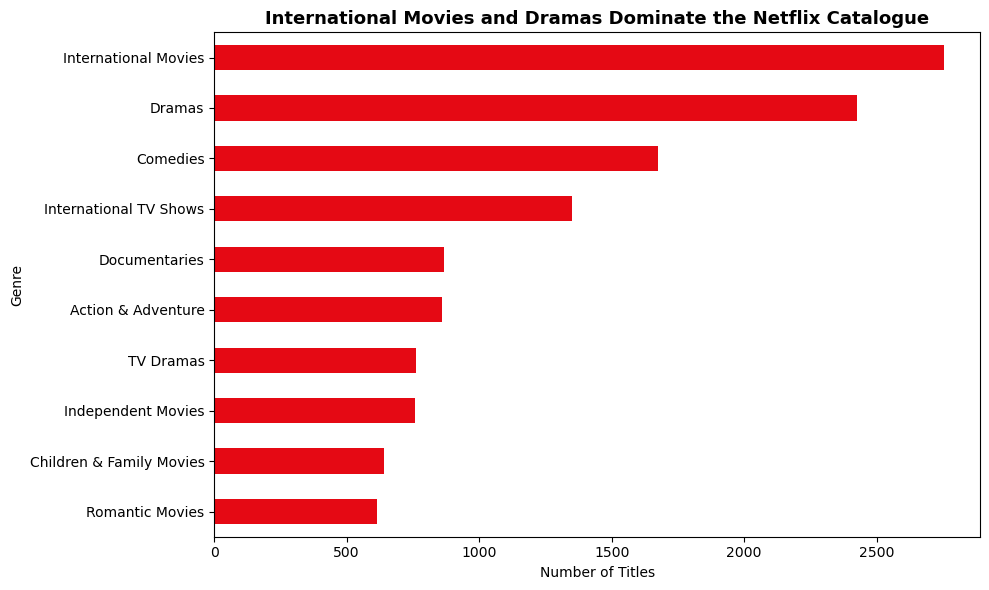

In [29]:
plt.figure(figsize=(10,6))
top_genres.sort_values().plot(kind='barh', color='#E50914')
plt.title('International Movies and Dramas Dominate the Netflix Catalogue', fontsize=13, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('images/top_genres.png', dpi=150)
plt.show()

### Most Common Genres
International Movies (2,752), Dramas (2,426), and Comedies (1,674) are the most common genres. The strong presence of "International" categories reflects Netflix's globally diverse catalogue.

In [36]:
# How have ratings evolved over time?
recent = df[df['year_added'] >= 2015]
rating_trends = recent.groupby(['year_added', 'rating']).size().unstack(fill_value=0)

#  Just the most common ratings to keep the chart in a readable format
top_ratings = df['rating'].value_counts().head(5).index
rating_trends = rating_trends[top_ratings]
print(rating_trends)

rating      TV-MA  TV-14  TV-PG    R  PG-13
year_added                                 
2015           29     14      8    3      2
2016          162     98     50   14      6
2017          446    326    168   66     26
2018          650    451    184  129     53
2019          736    494    198  208    135
2020          671    439    146  188    122
2021          489    326     97  190    146


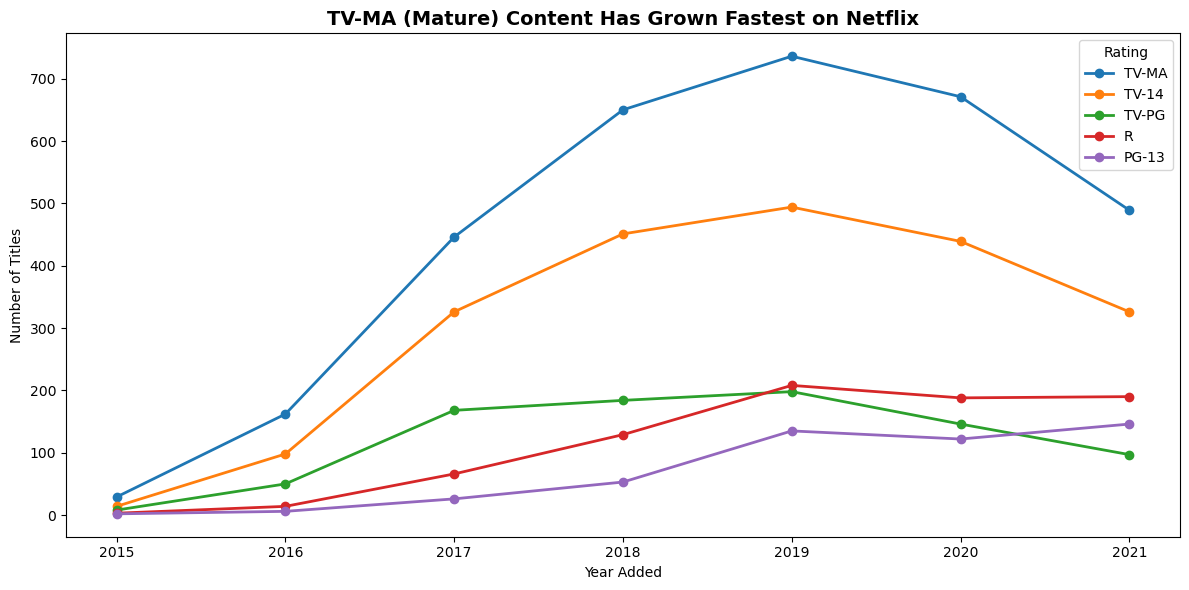

In [37]:
plt.figure(figsize=(12,6))
for rating in rating_trends.columns:
    plt.plot(rating_trends.index, rating_trends[rating], marker='o', label=rating, linewidth=2)
plt.title('TV-MA (Mature) Content Has Grown Fastest on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(title='Rating')
plt.tight_layout()
plt.savefig('images/rating_trends.png', dpi=150)
plt.show()

### Content Ratings Over Time
TV-MA (mature) is the most common rating every year and grew fastest, from 29 titles in 2015 to 736 in 2019. Netflix's catalogue skews heavily toward mature audiences, and this lean intensified as the platform scaled.